In [1]:
"""01_census_geometries_ingest.py"""

'01_census_geometries_ingest.py'

# Puerto Rico Census Geometries ingest

This notebook materializes the four Census geometry layers that the project
needs before any demographic or urban-rural analysis can run:

1. Municipalities (Puerto Rico counties equivalent)
2. Census tracts
3. Census block groups
4. Census blocks

The notebook now keeps its narrative flow in cells while delegating the raw
fetch and DuckDB persistence logic to `utils.census`.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from censusdis.maps import ShapeReader
from IPython.display import Image, display


def _bootstrap_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    markers = ("project_rules.md", ".git")
    for candidate in (current, *current.parents):
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    return current


PROJECT_ROOT = _bootstrap_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.census import CENSUS_LAYER_ORDER
from utils.census import create_spatial_connection
from utils.census import fetch_prepared_census_geography
from utils.census import get_census_layer_spec
from utils.census import list_db_tables
from utils.census import preview_geometry_samples
from utils.census import preview_table_rows
from utils.census import preview_table_schema
from utils.census import resolve_vector_db_path
from utils.census import upsert_geodataframe

CENSUS_YEAR = 2020
CENSUS_GEOGRAPHIES = CENSUS_LAYER_ORDER
AREA_CRS = "EPSG:32619"
CASE_STUDY_MUNICIPALITIES = ("San Juan", "Isabela")


def resolve_preview_output_dirs() -> tuple[Path, Path]:
    """Resolve output folders used for saved preview artifacts."""

    map_dir = PROJECT_ROOT / "outputs" / "maps"
    figure_dir = PROJECT_ROOT / "outputs" / "figures"
    map_dir.mkdir(parents=True, exist_ok=True)
    figure_dir.mkdir(parents=True, exist_ok=True)
    return map_dir, figure_dir


def fetch_project_geographies(year: int = CENSUS_YEAR) -> dict[str, object]:
    """Fetch the project Census geometry stack for a given vintage."""

    reader = ShapeReader(year=year)
    layers: dict[str, object] = {}
    for geography in CENSUS_GEOGRAPHIES:
        spec = get_census_layer_spec(geography)
        print(f"[fetch] {spec.geography_level} ({year}) …")
        layers[geography] = fetch_prepared_census_geography(reader, geography)
        print(f"        {len(layers[geography]):,} rows")
    return layers


def print_geometry_previews(layers: dict[str, object]) -> None:
    """Print a small preview of each fetched Census layer."""

    for geography in CENSUS_GEOGRAPHIES:
        spec = get_census_layer_spec(geography)
        print(f"\nSample geometries: {spec.table_name}")
        print(preview_geometry_samples(layers[geography], n=5).to_string(index=False))


def create_case_study_municipality_explore_map(
    municipalities: gpd.GeoDataFrame,
    output_dir: Path,
) -> tuple[object, Path]:
    """Create a folium-backed municipality overview with case-study highlighting."""

    explore_frame = municipalities.copy()
    explore_frame["study_status"] = explore_frame["NAME"].apply(
        lambda name: "Case study municipality" if name in CASE_STUDY_MUNICIPALITIES else "Other municipality"
    )
    explore_map = explore_frame.explore(
        column="study_status",
        categorical=True,
        cmap=["#cbd5e1", "#0f766e"],
        legend=True,
        tiles="CartoDB positron",
        tooltip=["NAME", "GEOID", "study_status"],
        style_kwds={"color": "#475569", "weight": 1.2, "fillOpacity": 0.4},
        legend_kwds={"caption": "Municipality role"},
        name="Puerto Rico municipalities",
    )
    output_path = output_dir / "pr_case_study_municipalities_explore.html"
    explore_map.save(str(output_path))
    return explore_map, output_path


def _filter_children_by_municipality(gdf: gpd.GeoDataFrame, county_fips: str) -> gpd.GeoDataFrame:
    return gdf[gdf["COUNTYFP"].astype(str).str.zfill(3) == county_fips].copy()


def _mean_area_m2(gdf: gpd.GeoDataFrame) -> float:
    if gdf.empty:
        return 0.0
    return float(gdf.to_crs(AREA_CRS).geometry.area.mean())


def _largest_geometry(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.empty:
        return gdf.copy()
    metric = gdf.to_crs(AREA_CRS)
    area_idx = metric.geometry.area.idxmax()
    return gdf.loc[[area_idx]].copy()


def _annotate_axis(ax, title: str, summary: str) -> None:
    ax.set_title(title, fontsize=12, pad=10)
    ax.text(
        0.02,
        0.02,
        summary,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cbd5e1", "boxstyle": "round,pad=0.35"},
    )
    ax.set_axis_off()


def plot_case_study_hierarchy_grid(layers: dict[str, object], output_dir: Path) -> Path:
    """Plot municipality, tract, block-group, and block hierarchy for the two case studies."""

    municipalities = layers["municipality"]
    tracts = layers["tract"]
    block_groups = layers["block_group"]
    blocks = layers["block"]

    fig, axes = plt.subplots(len(CASE_STUDY_MUNICIPALITIES), 3, figsize=(18, 10), constrained_layout=True)
    if len(CASE_STUDY_MUNICIPALITIES) == 1:
        axes = [axes]

    for row_index, municipality_name in enumerate(CASE_STUDY_MUNICIPALITIES):
        municipality = municipalities[municipalities["NAME"] == municipality_name].copy()
        if municipality.empty:
            raise RuntimeError(f"Missing municipality geometry for {municipality_name}.")

        county_fips = str(municipality.iloc[0]["COUNTYFP"]).zfill(3)
        municipality_tracts = _filter_children_by_municipality(tracts, county_fips)
        municipality_block_groups = _filter_children_by_municipality(block_groups, county_fips)
        municipality_blocks = _filter_children_by_municipality(blocks, county_fips)

        largest_tract = _largest_geometry(municipality_tracts)
        largest_bg = _largest_geometry(municipality_block_groups)

        focus_tractce = str(largest_tract.iloc[0]["TRACTCE"]).zfill(6) if not largest_tract.empty else None
        focus_bgce = str(largest_bg.iloc[0]["BLKGRPCE"]) if not largest_bg.empty else None

        tract_block_groups = municipality_block_groups[
            municipality_block_groups["TRACTCE"].astype(str).str.zfill(6) == focus_tractce
        ].copy() if focus_tractce else municipality_block_groups.iloc[0:0].copy()

        bg_blocks = municipality_blocks[
            (municipality_blocks["TRACTCE"].astype(str).str.zfill(6) == (str(largest_bg.iloc[0]["TRACTCE"]).zfill(6) if not largest_bg.empty else ""))
            & (municipality_blocks["BLOCKCE"].astype(str).str.zfill(4).str[0] == (focus_bgce or ""))
        ].copy() if focus_bgce else municipality_blocks.iloc[0:0].copy()

        ax_tracts = axes[row_index][0]
        municipality.boundary.plot(ax=ax_tracts, color="#111827", linewidth=1.6)
        if not municipality_tracts.empty:
            municipality_tracts.plot(ax=ax_tracts, color="#99f6e4", alpha=0.3, edgecolor="#0f766e", linewidth=0.6)
        _annotate_axis(
            ax_tracts,
            f"{municipality_name}: census tracts",
            f"tracts: {len(municipality_tracts):,}\navg tract area: {_mean_area_m2(municipality_tracts):,.0f} m²",
        )

        ax_bgs = axes[row_index][1]
        municipality.boundary.plot(ax=ax_bgs, color="#111827", linewidth=1.2)
        if not largest_tract.empty:
            largest_tract.plot(ax=ax_bgs, color="#bfdbfe", alpha=0.45, edgecolor="#1d4ed8", linewidth=1.0)
        if not tract_block_groups.empty:
            tract_block_groups.plot(ax=ax_bgs, color="#93c5fd", alpha=0.45, edgecolor="#2563eb", linewidth=0.5)
        _annotate_axis(
            ax_bgs,
            f"{municipality_name}: largest tract -> block groups",
            f"block groups: {len(municipality_block_groups):,}\navg BG area: {_mean_area_m2(municipality_block_groups):,.0f} m²\nfocus tract: {focus_tractce or 'n/a'}",
        )

        ax_blocks = axes[row_index][2]
        municipality.boundary.plot(ax=ax_blocks, color="#111827", linewidth=1.0)
        if not largest_bg.empty:
            largest_bg.plot(ax=ax_blocks, color="#fed7aa", alpha=0.5, edgecolor="#c2410c", linewidth=1.0)
        if not bg_blocks.empty:
            bg_blocks.plot(ax=ax_blocks, color="#fdba74", alpha=0.45, edgecolor="#ea580c", linewidth=0.35)
        _annotate_axis(
            ax_blocks,
            f"{municipality_name}: largest block group -> blocks",
            f"blocks: {len(municipality_blocks):,}\navg block area: {_mean_area_m2(municipality_blocks):,.0f} m²\nfocus BG: {focus_bgce or 'n/a'}",
        )

    output_path = output_dir / "pr_case_study_census_hierarchy.png"
    fig.savefig(output_path, dpi=240, bbox_inches="tight")
    plt.close(fig)
    return output_path


def persist_project_geographies(layers: dict[str, object], *, db_path: Path | None = None) -> Path:
    """Persist the fetched geometry layers into DuckDB and print quick previews."""

    target_db_path = db_path or resolve_vector_db_path()
    con = create_spatial_connection(target_db_path)

    try:
        print("Tables available before census ingest:")
        print(list_db_tables(con).to_string(index=False))

        for geography in CENSUS_GEOGRAPHIES:
            spec = get_census_layer_spec(geography)
            print(f"\n[persist] {spec.table_name} …")
            upsert_geodataframe(con, spec.table_name, layers[geography])

        print("\nTables available after census ingest:")
        print(list_db_tables(con).to_string(index=False))

        for geography in CENSUS_GEOGRAPHIES:
            spec = get_census_layer_spec(geography)
            print(f"\nTable schema preview: {spec.table_name}")
            print(preview_table_schema(con, spec.table_name).to_string(index=False))
            print(f"\nSample rows: {spec.table_name}")
            print(preview_table_rows(con, spec.table_name, limit=5).to_string(index=False))
    finally:
        con.close()

    return target_db_path

## Step 1 — Fetch the Puerto Rico geometry stack

Municipalities, tracts, and block groups come from the cartographic boundary
products. Census blocks use the TIGER block shapefiles because that is the
geometry family used by the urban-block reference product and the later
2020-versus-2024 comparison.

In [3]:
census_layers = fetch_project_geographies()

[fetch] municipality (2020) …
        78 rows
[fetch] tract (2020) …
        939 rows
[fetch] block_group (2020) …
        2,513 rows
[fetch] block (2020) …
        41,987 rows


## Step 2 — Preview the fetched vectors

This step now produces two case-study-oriented previews before persistence:

1. a Folium-backed `gdf.explore` overview of all 78 municipalities with San
   Juan and Isabela highlighted via legend, and
2. a 3 x 2 hierarchy grid showing tract, block-group, and block relationships
   for the two case-study municipalities.

In [4]:
map_output_dir, figure_output_dir = resolve_preview_output_dirs()
municipality_explore_map, municipality_explore_path = create_case_study_municipality_explore_map(
    census_layers["municipality"],
    map_output_dir,
)
hierarchy_grid_path = plot_case_study_hierarchy_grid(census_layers, figure_output_dir)
print(f"Saved municipality explore map to: {municipality_explore_path}")
display(municipality_explore_map)

Saved municipality explore map to: /home/asvnpr/Documents/repos/PLAN6068_PV_Project/outputs/maps/pr_case_study_municipalities_explore.html


Saved case-study hierarchy grid to: /home/asvnpr/Documents/repos/PLAN6068_PV_Project/outputs/figures/pr_case_study_census_hierarchy.png


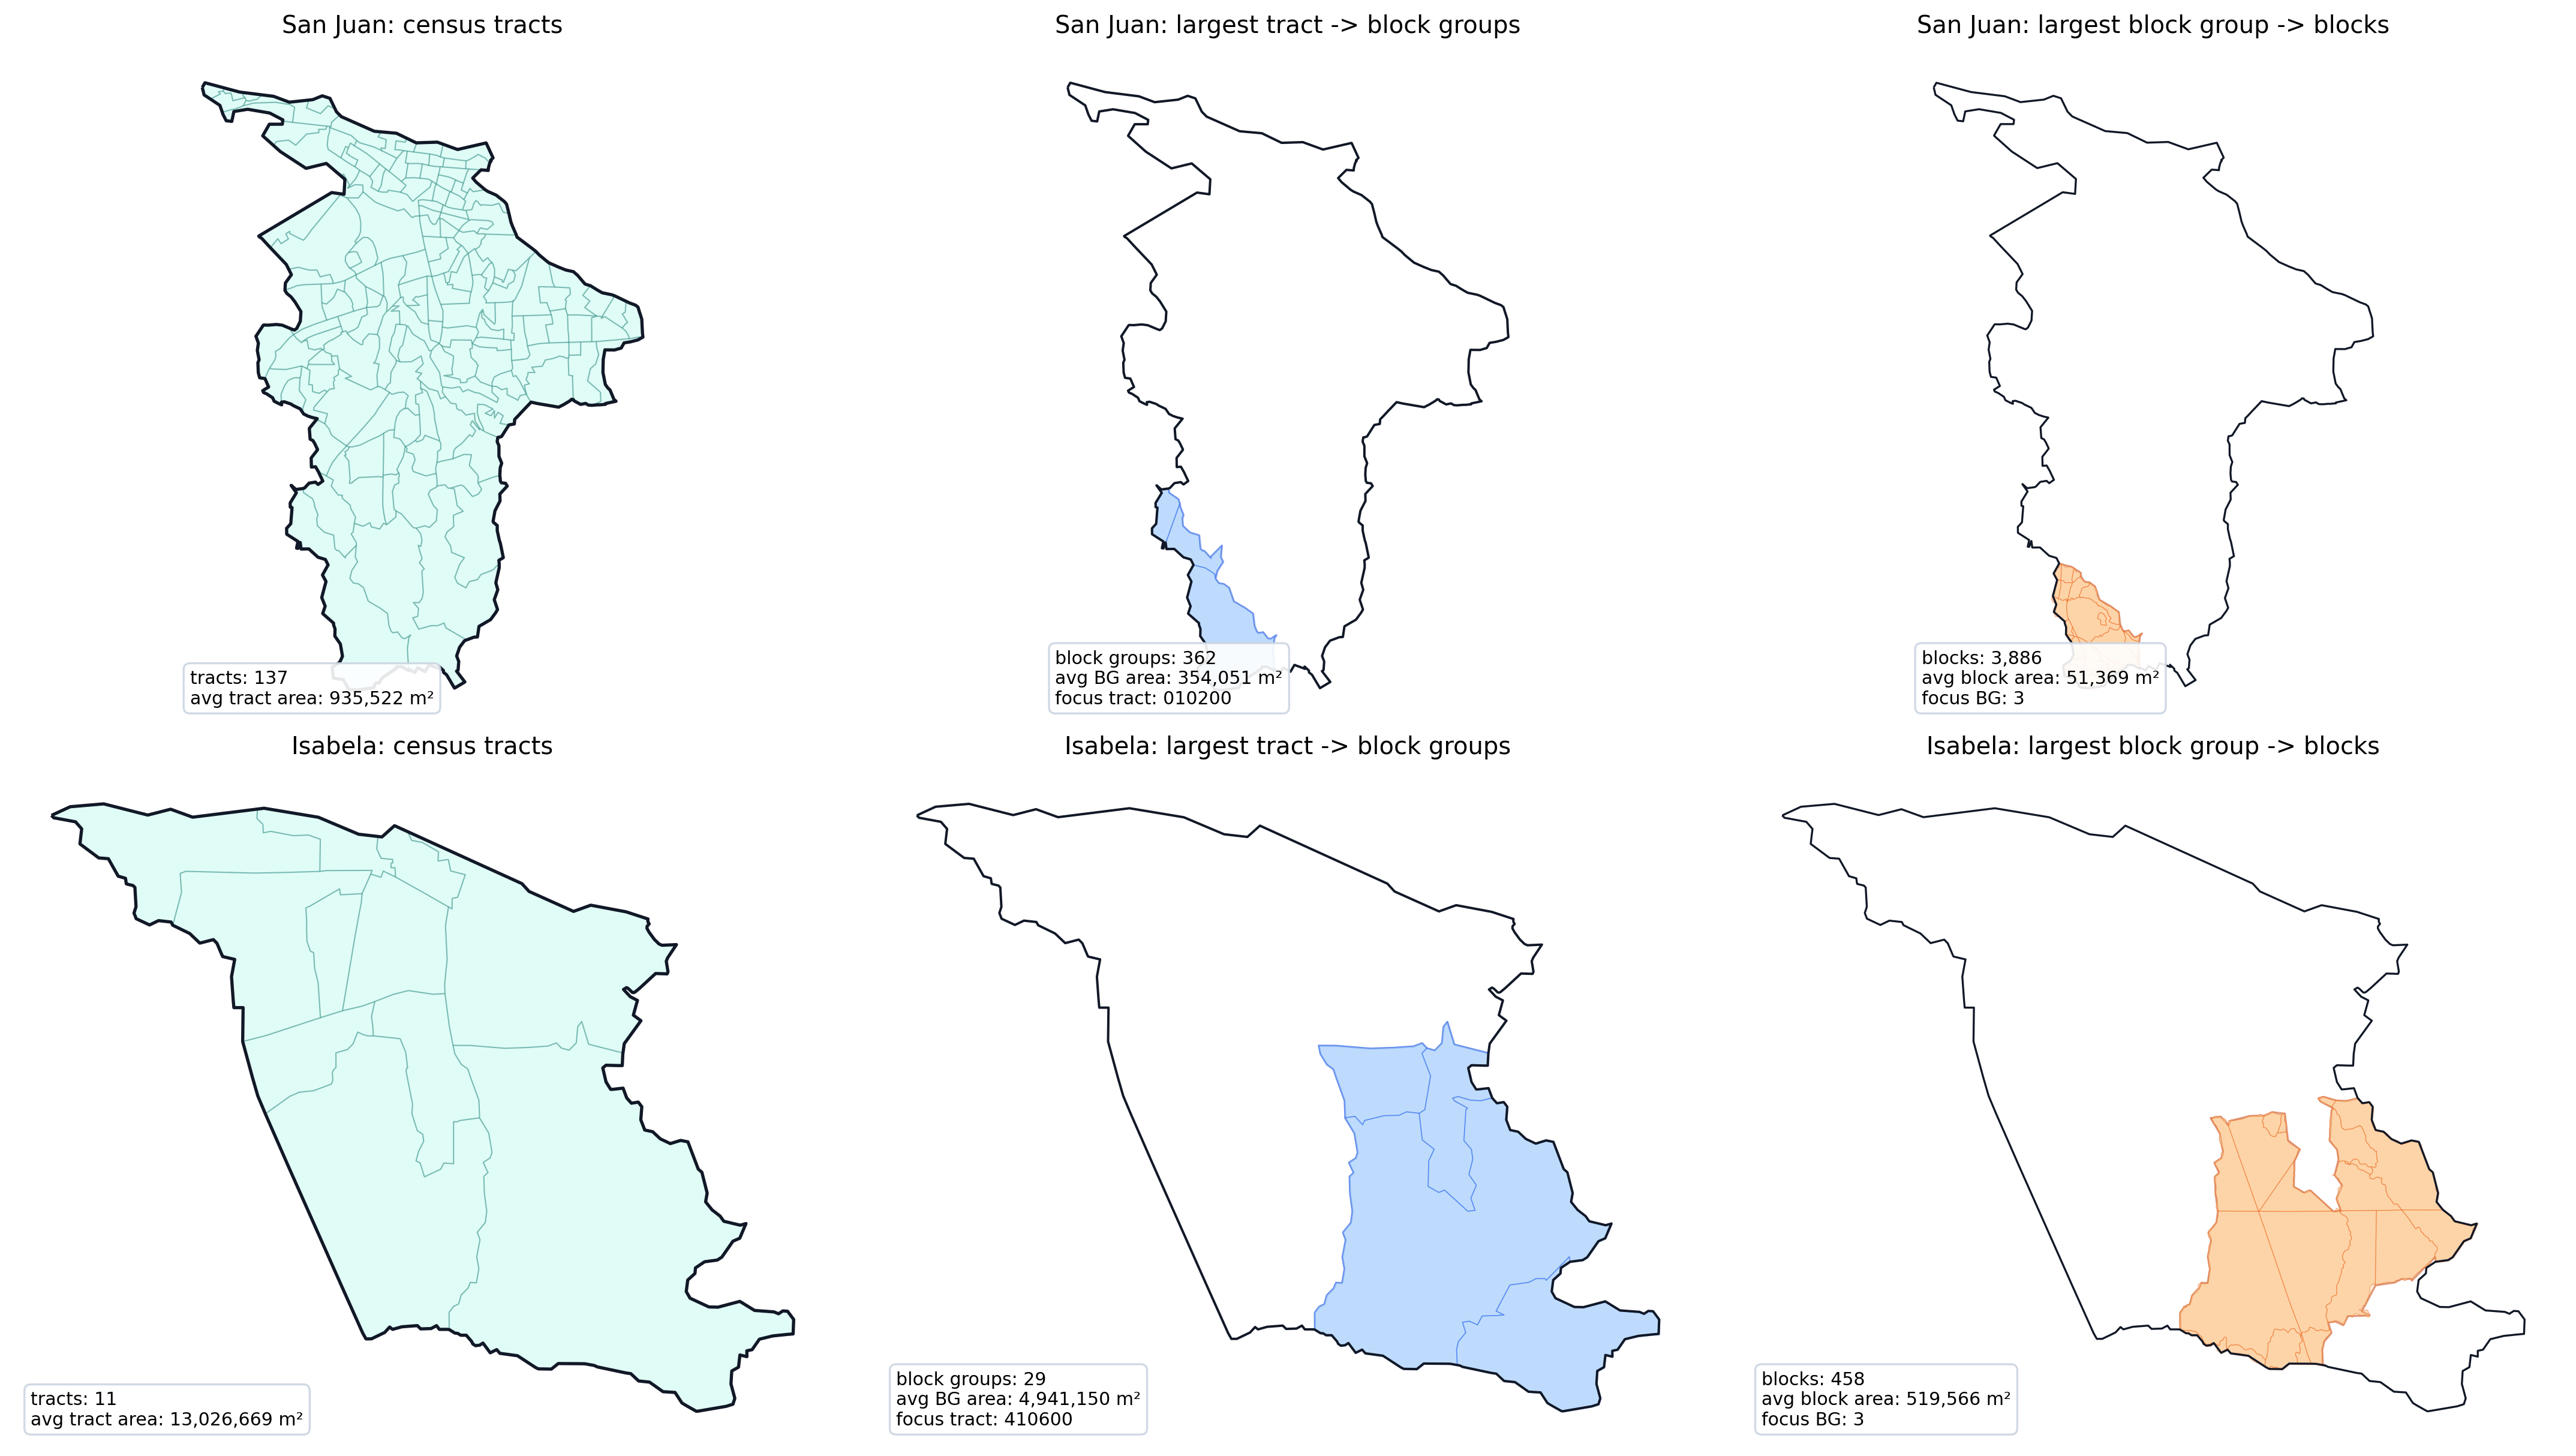

In [5]:
print(f"Saved case-study hierarchy grid to: {hierarchy_grid_path}")
display(Image(filename=str(hierarchy_grid_path)))

# print_geometry_previews(census_layers)

## Step 3 — Persist the layers into DuckDB

Each table is materialized with a native DuckDB `GEOMETRY` column and an
RTREE spatial index so later notebooks can use them directly.

In [6]:
db_path = persist_project_geographies(census_layers)
created_tables = [get_census_layer_spec(geography).table_name for geography in CENSUS_GEOGRAPHIES]
print(f"Saved DuckDB spatial database to: {db_path}")
print(f"Created tables: {', '.join(created_tables)}")

Tables available before census ingest:
Empty DataFrame
Columns: [table_name]
Index: []

[persist] pr_census_counties …

[persist] pr_census_tracts …

[persist] pr_census_block_groups …

[persist] pr_census_blocks …

Tables available after census ingest:
            table_name
pr_census_block_groups
      pr_census_blocks
    pr_census_counties
      pr_census_tracts

Table schema preview: pr_census_counties
    column_name column_type null  key default extra
geography_level     VARCHAR  YES None    None  None
        STATEFP     VARCHAR  YES None    None  None
       COUNTYFP     VARCHAR  YES None    None  None
          GEOID     VARCHAR  YES None    None  None
           NAME     VARCHAR  YES None    None  None
       geometry    GEOMETRY  YES None    None  None
         has_PV     BOOLEAN  YES None    None  None

Sample rows: pr_census_counties
geography_level STATEFP COUNTYFP GEOID     NAME                                                                                             